In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!pip install scikit-learn

* Load file, solutions/formationchannels.npy,  (np.load) and complete a quick exploration of the data. How many modes do you think you see?

* We'll use sklearn.mixture.GaussianMixture. You first need to define the model (instance of a class), and then train it on the data using the fit method (the data provided are already in the right numpy format!). This will output the trained model, which has various attributes.

* Complete the fit 10 times with $N=1,...,10$ Gaussians.

Note: sklearn by default will use the so-called Expectation-Maximization algorithm.

* For each of these fits, compute the AIC (easy! It's an attribute of the trained model!). Plot $N$ vs AIC: which model is preferred?

* Plot the preferred solution on top of the input data. You should get a very nice fit!

In [3]:
data=np.load('../solutions/formationchannels.npy')

In [4]:
data.shape

(2950, 1)

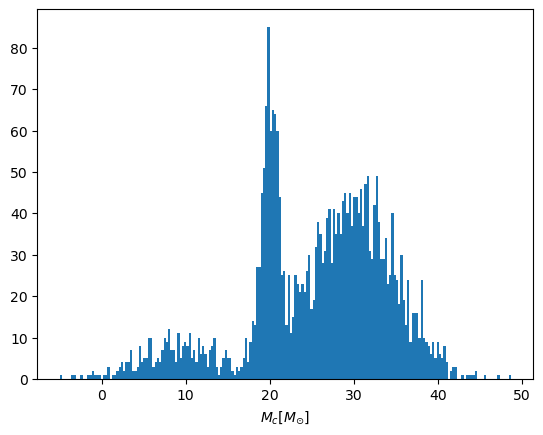

In [5]:
plt.hist(data, bins=200)
plt.xlabel(r'$M_c [M_{\odot}]$')
plt.show()

In [6]:
from sklearn.mixture import GaussianMixture
n=5
gm = GaussianMixture(n_components=n, random_state=0).fit(data)
gm.means_
#gm.predict

C:\Users\annat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


array([[31.20282448],
       [20.132288  ],
       [ 9.21578123],
       [26.22035689],
       [36.0651393 ]])

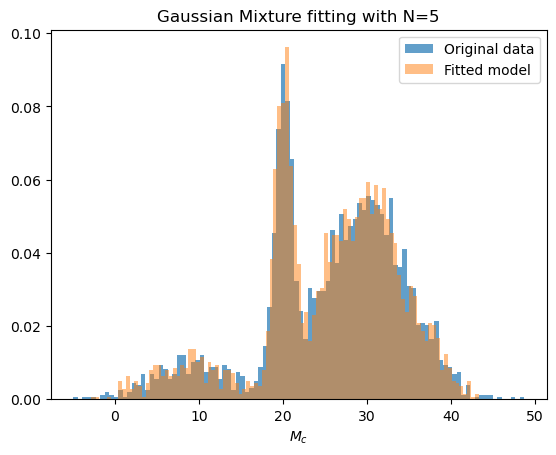

In [7]:
model_samples = gm.sample(n_samples=3000)[0]
plt.hist(data, bins=100, density='True', alpha=0.7, label='Original data')
plt.hist(model_samples, density='True', bins=100, alpha=0.5, label='Fitted model')
plt.xlabel(r'$M_c$')
plt.title(f'Gaussian Mixture fitting with N={n}')
plt.legend()
plt.show()

C:\Users\annat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\annat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\annat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\annat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Win

Text(0.5, 0.98, 'Gaussian mixture fitting')

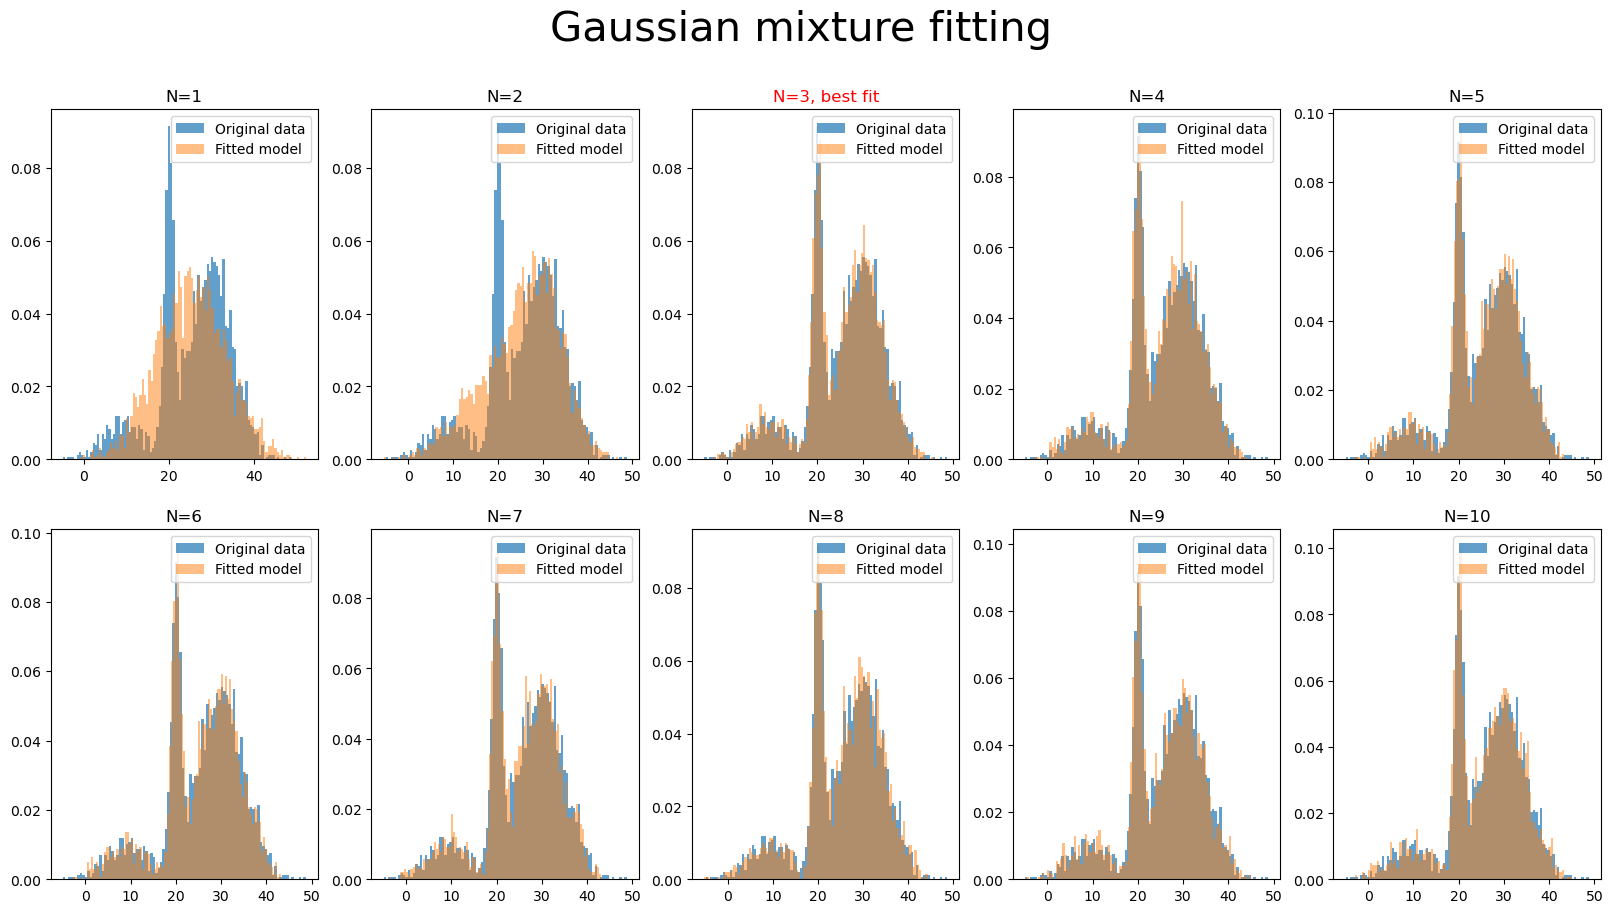

In [10]:
fig, ax =plt.subplots(2,5, figsize=(20,10))

fit_results = []
for i in range(2):
    for j in range(5):
        n = 4*i+j+1
        gm = GaussianMixture(n_components=n, random_state=0).fit(data)
        fit_results.append(gm.aic(data))
        ax[i,j].hist(data, bins=100, density='True', alpha=0.7, label='Original data')
        ax[i,j].hist(gm.sample(n_samples=3000)[0], density='True', bins=100, alpha=0.5, label='Fitted model')
        ax[i,j].legend()
best=np.argmin(fit_results)
for i in range(2):
    for j in range(5):
        n = 5*i+j+1
        if 4*i+j+1==best+1:
            ax[i,j].set_title(f'N={n}, best fit', color='red')
        else:
            ax[i,j].set_title(f'N={n}')
fig.suptitle('Gaussian mixture fitting', size=30)

Text(0.5, 1.0, 'AIC vs N modes')

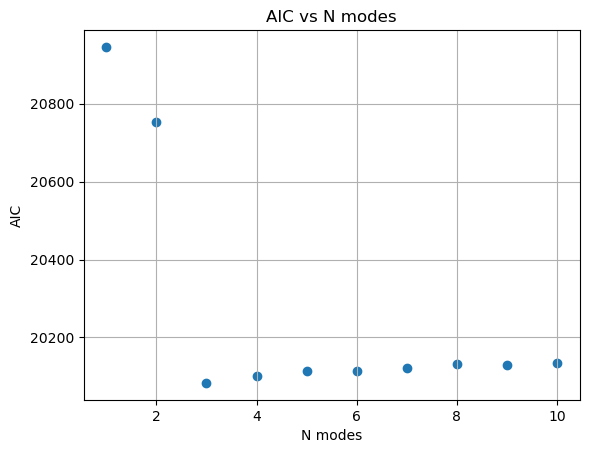

In [19]:
plt.scatter(np.arange(0,10)+1, fit_results)
plt.xlabel('N modes')
plt.ylabel('AIC')
plt.grid()
plt.title('AIC vs N modes')


Class labels are a very interesting by product of a mixture analysis. What is the probability that a given gravitational-wave event comes from a given channel? This is called "responsiblity" (i.e. which mode is most likely to be responsible for that piece of data).

* Understand (i.e. plot) which Gaussian mode corresponds to which part of the input dataset.

Hint: Useful methods here are score_samples and predict_proba.

In [25]:
from sklearn.mixture import GaussianMixture
n=3
gm = GaussianMixture(n_components=n, random_state=0).fit(data)
prob = gm.predict_proba(data)

C:\Users\annat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


In [26]:
prob.shape

(2950, 3)

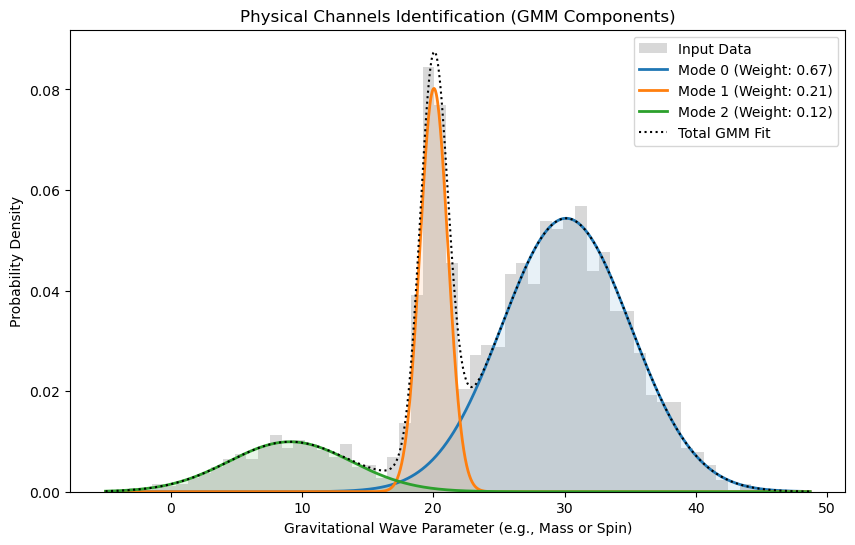

In [32]:
from scipy.stats import norm

x = np.linspace(data.min(), data.max(), 1000).reshape(-1, 1)
means = gm.means_.flatten()
weights = gm.weights_
vars = gm.covariances_.flatten()

plt.figure(figsize=(10, 6))

plt.hist(data, bins=60, density=True, alpha=0.3, color='gray', label='Input Data')


for i in range(gm.n_components):
   #pdf of single i component
    std = np.sqrt(vars[i])
    p = weights[i] * norm.pdf(x, means[i], std)
    
    plt.plot(x, p, label=f'Mode {i} (Weight: {weights[i]:.2f})', lw=2)
    plt.fill_between(x.flatten(), 0, p.flatten(), alpha=0.1)

# Total likelihood
logprob = gm.score_samples(x)
plt.plot(x, np.exp(logprob), color='black', linestyle=':', label='Total GMM Fit')

plt.title("Physical Channels Identification (GMM Components)")
plt.xlabel("Gravitational Wave Parameter (e.g., Mass or Spin)")
plt.ylabel("Probability Density")
plt.legend()
plt.show()